# GLM

- In this notebook we run GLM analysis for before and after button press periods for the MEI dataset

In [193]:
import nibabel as nib

from nilearn.input_data import NiftiMasker , MultiNiftiMasker, NiftiLabelsMasker
import nilearn as nil
import numpy as np 
import os
import os.path
import scipy.io
import nibabel as nib
import sys  
import random


from brainiak import image, io
from brainiak.io import load_boolean_mask
import brainiak.utils.fmrisim as sim  

from scipy.stats import stats
import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt

import pandas as pd

#plot_roi(x)
from nilearn.image import concat_imgs, resample_img, mean_img
from nilearn.plotting import view_img
from nilearn import datasets, plotting
from nilearn.plotting import plot_glass_brain


from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.image import concat_imgs, resample_img, mean_img,index_img
from nilearn import image
from nilearn import masking
from nilearn.plotting import view_img
from nilearn.image import resample_to_img
from scipy.spatial.distance import squareform
# Visualize it as an ROI

from nilearn import image
from nilearn.image import math_img
from utils_anal import load_epi_data


random.seed(10)


# In[8]:



# Variables

### Directories 

In [194]:

top_dir = '/jukebox/graziano/coolCatIsaac/mei'
data_dir = top_dir + "/data"
work_dir = data_dir + '/work'
mask_dir = work_dir + '/masks'
behav_dir = top_dir + '/data/behavioral'
rois_dir = data_dir + "/rois"
fmri_prep = data_dir + '/bids/derivatives/fmriprep'
conf_dir = work_dir + '/confs'
preproc_dir = work_dir + '/glm_preproc'
fmri_glm_dir = work_dir + '/glm_data'
glm_sav_dir = work_dir + '/glm_out'

# Check if the directory exists, and create it if it doesn't
if not os.path.exists(glm_sav_dir):
    os.makedirs(glm_sav_dir)
    print(f"Directory created: {glm_sav_dir}")
    

### Sublist

In [195]:
'''
# sub-012 -- had to postprocess, see subject notes, remove for ease
- Incorrect specification of additional regressors: length of regressors provided: 70, number of time-frames: 102
# sub-014 -- no button presses
IndexError: list index out of range
# sub-015 - no button presses collected for INTERNAL due to malfunction. fMRI data okay
IndexError: list index out of range
# sub-020 -- no button presses 
IndexError: list index out of range
# sub-037
IndexError: list index out of range -- no button presses
'''
## all subjects ## 
sub_list = [
    'sub-002', 'sub-003', 'sub-004', 'sub-005','sub-006','sub-007','sub-008','sub-009','sub-010',
    'sub-013', 'sub-015', 'sub-016','sub-017','sub-018','sub-019','sub-020','sub-021',
    'sub-022','sub-023','sub-024','sub-025','sub-026','sub-027','sub-028', 'sub-029', 'sub-030','sub-031','sub-032',
    'sub-033','sub-034','sub-035','sub-036','sub-037','sub-038','sub-039','sub-040', 'sub-041'
]
## subjects with bpress data 
sub_list = [
    'sub-002', 'sub-003', 'sub-004', 'sub-005','sub-006','sub-007','sub-008','sub-009','sub-010',
    'sub-013', 'sub-016','sub-017','sub-018','sub-019','sub-022','sub-023','sub-024','sub-025',
    'sub-026','sub-027','sub-028', 'sub-029', 'sub-030','sub-031','sub-032',
    'sub-033','sub-034','sub-035','sub-036','sub-038','sub-039','sub-040', 'sub-041'
]


In [196]:
len(sub_list)

33

# masking 

In [197]:
##### MASKING #### 

# Set the size (in terms of X, Y, Z) of the volume we want to create
dimensions = np.asarray([78, 93, 65])

# Generate an anatomical image with the size above of brain voxels in gray matter
# This outputs variables for two versions of the image, binary (mask) and probabilistic (template)
mask, template = sim.mask_brain(dimensions, mask_self=False)
s_dat = np.load(f'{fmri_glm_dir}/sub-004_bpress_fmri_data.npy', allow_pickle=True).item() # load template data to get affine
epi = s_dat['external']['sherlock']['f'][0]
mask_3d = nib.Nifti1Image(mask, epi.affine) ##create nifti image

# GLM 

In [198]:
fmri_glm = FirstLevelModel(t_r=1.5,
                           signal_scaling=False,
                           hrf_model = 'glover',
                           drift_order=None,
                           high_pass=None,
                           mask_img=mask_3d,
                           drift_model=None,
                           smoothing_fwhm=4,
                           standardize=True,
                           minimize_memory=False)

## other GLM vars
#comp_onset_list = [-3,0]
comp_onset_list = [-3,0]
stim_dur = 3 # how long is the stimuous on
window_list = ['win' + str(i+1) for i in range(len(comp_onset_list))] ## which windows to include for GLM


In [199]:
def create_event_list(bpress, comp_onset_list, stim_dur):
    """
    this function reads in a condition for each sub
    and returns the corresponding b4 + after events
    
    sub: subject number
    bpress: array of button press onset times
    cond: which condition do you want to create event dataframe fore
    """
    all_tims = []
    #events = {}
    events = []
    # Convert to array #
    bpress_arr = np.asarray(bpress)
    # Select runs to include according to run_dic, append
    #all_tims = all_tims + list(bpress_arr[run_dic[sub][cond]])
    # include all
    all_tims = bpress


    # events will take  the form of a dictionary of Dataframes, one per run! 
    for run in range(len(all_tims)):
        cond_labs = []
        duration = []
        onsets = []
        bpress_onsets = all_tims[run]
        # Do base first, then iterate on windows # 

        for idx, comp_onset in enumerate(comp_onset_list):
            # Create a list of 'press' for how many presses there were for each run
            
            # label evaluates to 'win1'
            cond_labs = cond_labs + ['win'+str(idx+1)]* len(all_tims[run])

            # How long does the button event event last? one tr, so 1.5
            duration = duration + [stim_dur] * len(all_tims[run])

            # these are the corresponding onset times
            onsets = onsets +  [y + comp_onset for y in bpress_onsets]
        # Define the events object
        events_ = pd.DataFrame(
            {'onset': onsets, 'trial_type': cond_labs, 'duration': duration})
        # remove the rest condition and insert into the dictionary
        #events[run_num+run] = events_
        events.append(events_)
    return events

### run

In [200]:
'''
int_ext_glm.npy : no confounds, only up until sub-032, ONLY win1, which is -3 to 0, internal and external. no win2
n34_int_ext_glm.npy : no confounds, 34 subs
n33_int_ext_glm_conf.npy : confounds, 34 subs, win1 and win2 with mask

'''


anal_sav_name = f'n{len(sub_list)}_int_ext_conf_glm.npy'
print(f'analysis name: {anal_sav_name}')

analysis name: n33_int_ext_conf_glm.npy


In [ ]:
sub_list = [
    'sub-008','sub-009','sub-010',
    'sub-013', 'sub-016','sub-017','sub-018','sub-019','sub-022','sub-023','sub-024','sub-025',
    'sub-026','sub-027','sub-028', 'sub-029', 'sub-030','sub-031','sub-032',
    'sub-033','sub-034','sub-035','sub-036','sub-038','sub-039','sub-040', 'sub-041'
]

In [ ]:
cond_list = ['external', 'internal']
#s_glm_out = {}
#a_name = 'n34_int_ext_conf_glm.npy'
s_glm_out = np.load(os.path.join(glm_sav_dir, anal_sav_name), allow_pickle = True).item()


for sub in sub_list:
    print(f'\n* STARTING {sub} *')
    s_dat = np.load(f'{fmri_glm_dir}/{sub}_bpress_fmri_data.npy', allow_pickle=True).item()
    cond_dic = {}

    
    for cond in cond_list:
        events_across_mov = []
        bold_across_mov = []
        c_across_mov = []
        frame_times = []
        movie_list = list(s_dat[cond].keys()) # set movie list
        
        for m in movie_list: # get movie names. not necessary to know which movies
            print(f'movie {m} SLAPS')
            # get bpresses
            s_bpress = s_dat[cond][m]['b']
            if len(s_bpress) == 0: continue ## skip if no data... this is weird tho

            events = create_event_list(s_bpress, comp_onset_list,stim_dur)
            #print(events)
            #events_across_mov.update(events) # merge dictionaries across movie
            events_across_mov = events_across_mov + events
            #print(f'\nBOLD', len(s_dat[cond][m]['f']))

            # get fMRI
            bold_across_mov = bold_across_mov + s_dat[cond][m]['f'] # add to existing
            # confounds
            c_across_mov = c_across_mov + s_dat[cond][m]['c'] # add to existing
            # frametimes
            f_tem1 = [s_dat[cond][m]['f'][0].shape[3]] * len(s_dat[cond][m]['f'])
            f_tem2 =[np.arange(i) * 1.5 for i in f_tem1]
            frame_times = frame_times + f_tem2
            
        events_across_mov_d = {idx: ev for idx, ev in enumerate(events_across_mov)}
        
        if len(events_across_mov_d) == 0: continue # if not bpresses for this condition, skip - for sub-015
            
        # Create design matrix 
        # regressors
        design_matrices = [make_first_level_design_matrix(frame_times[df], events_across_mov_d[df], hrf_model = 'glover',
                      drift_model=None, add_regs=c_across_mov[df]) for df in events_across_mov_d]
        # no regressors 
        #design_matrices = [make_first_level_design_matrix(frame_times[df], events_across_mov_d[df], hrf_model = 'glover',
         #             drift_model=None) for df in events_across_mov_d]
        
        
        ## Run GLM ##
        s_glm_win = {}
        for win in window_list:
            
            print(f'processing {sub} {cond} {win}')
            # group sub glm is now a nested dictionary with three contrasts
            ## COND A ## 
            fmri_glm = fmri_glm.fit(bold_across_mov, design_matrices=design_matrices) 
            # Compute contrasts #
            beta_map = fmri_glm.compute_contrast(
                    win, output_type='effect_size') #effect_size
            
            # Save INDIVIDUAL WITHIN CONTRASTS
            s_glm_win[win] = beta_map 
            nib.save(beta_map, os.path.join(glm_sav_dir, '%s_%s_%s_bmap.nii') %(sub, cond, win))
            print('finish',win)
            
        cond_dic[cond] = s_glm_win
    s_glm_out[sub] = cond_dic
    print('finish', sub)
    np.save(os.path.join(glm_sav_dir, anal_sav_name), s_glm_out)


In [153]:
glm_sav_dir, anal_sav_name

('/jukebox/graziano/coolCatIsaac/mei/data/work/glm_out',
 'n34_int_ext_conf_glm.npy')

In [122]:
int(s[-1])

4

In [107]:
s_dat['internal']['shrek']['c'][2].shape

(94, 23)

In [124]:
for cond in cond_list:

    movie_list = list(s_dat[cond].keys()) # set movie list

    for m in movie_list: # get movie names. not necessary to know which movies
        print(f"movie {m} len {len(s_dat[cond][m]['c'])}")
        for i in s_dat[cond][m]['c']:
            print(i.shape)

movie office len 4
(106, 25)
(106, 25)
(106, 25)
(106, 25)
movie cake len 4
(103, 24)
(103, 24)
(103, 24)
(103, 24)
movie brushing len 4
(92, 23)
(92, 23)
(92, 23)
(92, 23)
movie shrek len 3
(94, 24)
(94, 24)
(92, 24)
movie sherlock len 4
(102, 24)
(102, 24)
(102, 24)
(102, 24)
movie oragami len 4
(86, 23)
(86, 23)
(86, 23)
(86, 23)


In [78]:
len(s_dat['external']['brushing']['c'])

3

In [149]:
s_dat['internal']['shrek']['c'][2] = arr 

In [150]:
s_dat['internal']['shrek']['c'][2].shape

(94, 24)

In [ ]:
s_dat['internal']['shrek']['c'][3]

In [151]:
np.save(f'{fmri_glm_dir}/{sub}_bpress_fmri_data.npy', s_dat)

In [62]:
f'{fmri_glm_dir}/{sub}_bpress_fmri_data.npy'

'/jukebox/graziano/coolCatIsaac/mei/data/work/glm_data/sub-029_bpress_fmri_data.npy'

In [73]:
s_dat['external'].keys()

dict_keys(['brushing', 'office'])

In [55]:
s_dat['internal']

{'sherlock': {'b': [[29.329998874105513,
    43.51712386007421,
    51.68820484098978,
    67.54912856803276,
    81.95112867513672,
    119.28201915207319,
    123.23814518400468,
    129.58514493401162,
    139.22712982213125],
   [29.186670490074903,
    83.46968725300394,
    114.82862674118951,
    120.6546779780183,
    127.55862302705646,
    133.82662503002211,
    143.05668096616864],
   [28.523058424005285,
    40.88098493288271,
    51.00198899186216,
    56.9889952968806,
    66.34896146296524,
    83.6669910068158,
    95.45588328083977,
    103.0719584277831,
    117.9959722389467,
    121.03099755896255,
    127.34299767296761,
    133.0441021048464,
    141.12501024687663],
   [23.989276549080387,
    31.864212106913328,
    36.11118906806223,
    61.31523234001361,
    65.51423148997128,
    78.48021966195665,
    83.83629494393244,
    90.34521408309229,
    111.89020350202918,
    127.11523110698909,
    132.24221470905468,
    139.16623409301974,
    140.79722498101

In [136]:
c_across_mov[2].shape

(92, 24)

In [137]:
arr = np.zeros((94,24))
arr[:c_across_mov[2].shape[0], :c_across_mov[2].shape[1]] = c_across_mov[2]


In [139]:
arr.shape

(94, 24)

In [19]:
c_across_mov[2].shape

(102, 22)

In [44]:
sub_dic_behav = np.load(os.path.join(behav_dir, f'{sub}_behav.npy'), allow_pickle=True).item()

In [46]:
sub_dic_behav['Internal']

{'oragami': {'run-1': {'start_tr': 8, 'end_tr': 94, 'bpress': -1},
  'run-2': {'start_tr': 97, 'end_tr': 183, 'bpress': -1},
  'run-3': {'start_tr': 189, 'end_tr': 275, 'bpress': -1},
  'run-4': {'start_tr': 276, 'end_tr': 362, 'bpress': -1}},
 'shrek': {'run-1': {'start_tr': 7, 'end_tr': 101, 'bpress': -1},
  'run-2': {'start_tr': 101, 'end_tr': 195, 'bpress': -1},
  'run-3': {'start_tr': 195, 'end_tr': 289, 'bpress': -1},
  'run-4': {'start_tr': 289, 'end_tr': 383, 'bpress': -1}},
 'sherlock': {'run-1': {'start_tr': 29, 'end_tr': 131, 'bpress': -1},
  'run-2': {'start_tr': 131, 'end_tr': 233, 'bpress': -1},
  'run-3': {'start_tr': 233, 'end_tr': 335, 'bpress': -1},
  'run-4': {'start_tr': 336, 'end_tr': 438, 'bpress': -1}}}

In [39]:
s_dat['external']['office']['c'][3]

'sub-029'

In [44]:
s_dat['external']['office']['c'][3].shape

(106, 25)

In [525]:
complete_s_glm_out = np.load(os.path.join(glm_sav_dir, f'{len(sub_list)}_int_ext_glm.npy'), allow_pickle = True).item()

for sub in s_glm_out:
    for c in ['external', 'internal']:
        complete_s_glm_out[sub][c]['win3'] = s_glm_out[sub][c]['win1']
        print(sub)

sub-002
sub-002
sub-003
sub-003
sub-004
sub-004
sub-005
sub-005
sub-006
sub-006
sub-007
sub-007
sub-008
sub-008
sub-009
sub-009
sub-010
sub-010
sub-013
sub-013
sub-016
sub-016
sub-017
sub-017
sub-018
sub-018
sub-019
sub-019
sub-022
sub-022
sub-023
sub-023
sub-024
sub-024
sub-025
sub-025
sub-026
sub-026
sub-027
sub-027
sub-028
sub-028
sub-029
sub-029
sub-030
sub-030
sub-031
sub-031
sub-032
sub-032
sub-033
sub-033
sub-034
sub-034
sub-035
sub-035
sub-036
sub-036
sub-038
sub-038
sub-039
sub-039
sub-040
sub-040
sub-041
sub-041


In [521]:
anal_sav_name

'33_int_ext_glm.npy'

In [526]:
complete_s_glm_out['sub-003']['external']

{'win1': <nibabel.nifti1.Nifti1Image at 0x7fcf5037ab10>,
 'win2': <nibabel.nifti1.Nifti1Image at 0x7fcf5037ac10>,
 'win3': <nibabel.nifti1.Nifti1Image at 0x7fd1fa8bd210>}

In [527]:
np.save(os.path.join(glm_sav_dir, anal_sav_name), complete_s_glm_out)

'/jukebox/graziano/coolCatIsaac/mei/data/work/glm_out'

## both

/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/ipykernel_launcher.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


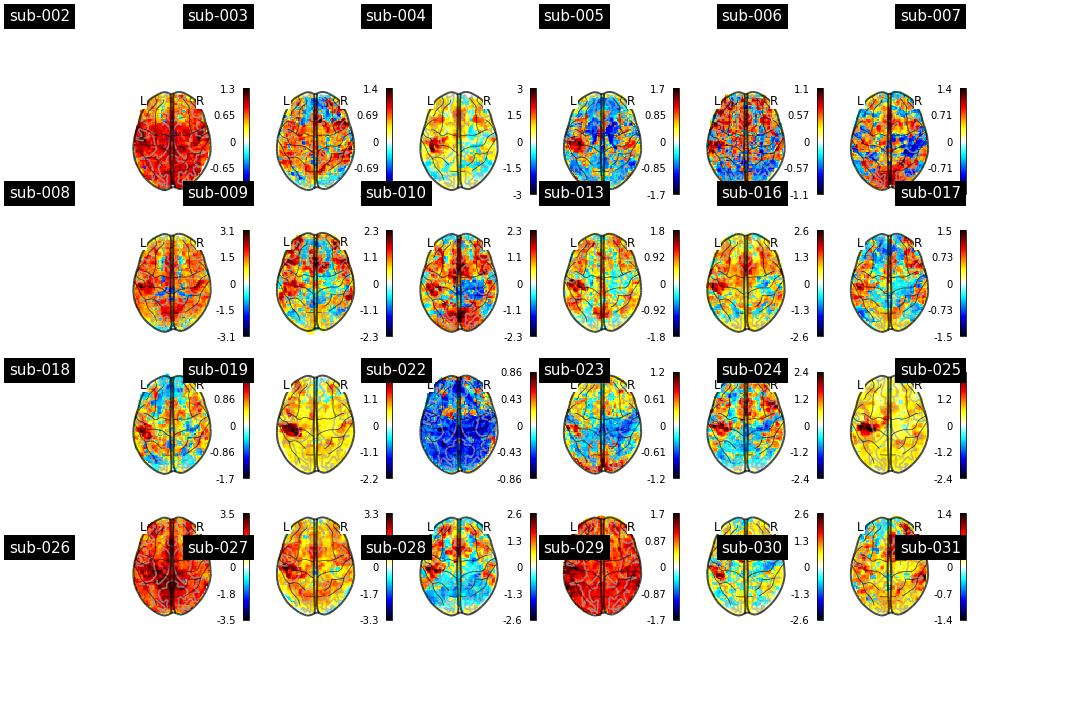

In [449]:
# Assuming `s_glm_out` is a dictionary with NIfTI-like images as values
# and the keys are the names of the corresponding maps.
c = 'internal'


num_keys = len(s_glm_out.keys())
keys = list(s_glm_out.keys())

# Determine subplot grid dimensions
rows = int(num_keys ** 0.5)
cols = (num_keys + rows - 1) // rows  # Ensure enough columns for all plots

# Create a figure for the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

# Flatten axes for easy indexing
axes = axes.flatten()

left_premotor_coords = (-40, -20, 60)


# Plot each stat map
for i, key in enumerate(list(s_glm_out.keys())):
    ax = axes[i]
    # Plot the stat map corresponding to the current key
    '''
    plot_stat_map(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        cut_coords=left_premotor_coords,
        colorbar=True,
        display_mode='ortho'  # Adjust to your preferred display mode
    )
    '''
    # Plot the glass brain corresponding to the current key
    display = plot_glass_brain(
        s_glm_out[key][c]['win1'],
        axes=ax,
        title=key,
        colorbar=True,
        display_mode='z',  # Axial view only
        plot_abs=False  # Set to True if absolute values are preferred
    )
    
# Hide any unused subplots if keys are fewer than subplots
for j in range(len(keys), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


## external

/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/ipykernel_launcher.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


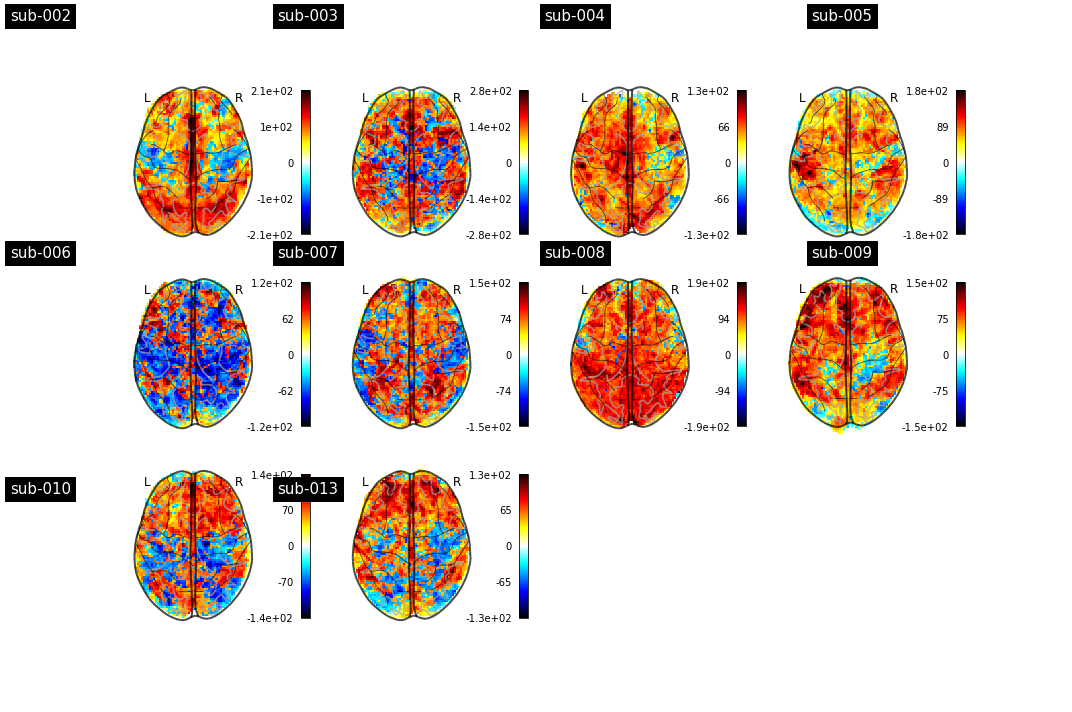

In [424]:
# Assuming `s_glm_out` is a dictionary with NIfTI-like images as values
# and the keys are the names of the corresponding maps.
c = 'external'


num_keys = len(s_glm_out.keys())
keys = list(s_glm_out.keys())

# Determine subplot grid dimensions
rows = int(num_keys ** 0.5)
cols = (num_keys + rows - 1) // rows  # Ensure enough columns for all plots

# Create a figure for the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

# Flatten axes for easy indexing
axes = axes.flatten()

left_premotor_coords = (-40, -20, 60)


# Plot each stat map
for i, key in enumerate(list(s_glm_out.keys())):
    ax = axes[i]
    # Plot the stat map corresponding to the current key
    '''
    plot_stat_map(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        cut_coords=left_premotor_coords,
        colorbar=True,
        display_mode='ortho'  # Adjust to your preferred display mode
    )
    '''
    # Plot the glass brain corresponding to the current key
    display = plot_glass_brain(
        s_glm_out[key][c]['win1'],
        axes=ax,
        title=key,
        colorbar=True,
        display_mode='z',  # Axial view only
        plot_abs=False  # Set to True if absolute values are preferred
    )
    
# Hide any unused subplots if keys are fewer than subplots
for j in range(len(keys), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


## internal

In [408]:
s_glm_out['sub-002']['internal']

{'win1': <nibabel.nifti1.Nifti1Image at 0x7fd0cb239a90>}

/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/ipykernel_launcher.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


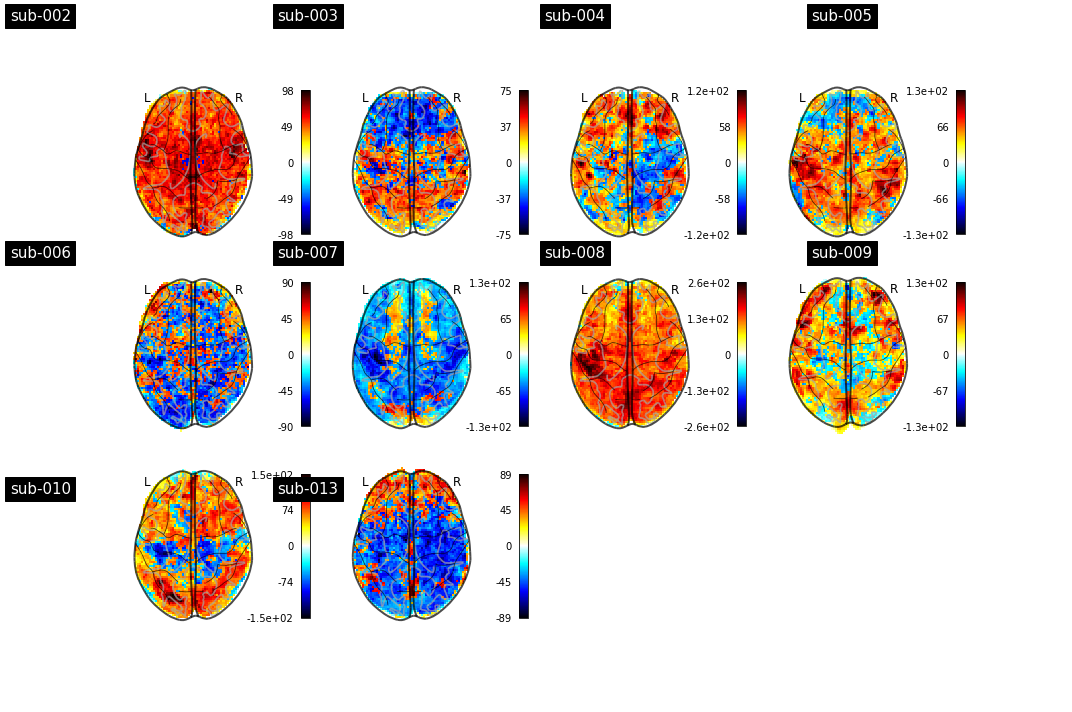

In [409]:
# Assuming `s_glm_out` is a dictionary with NIfTI-like images as values
# and the keys are the names of the corresponding maps.
c = 'internal'


num_keys = len(s_glm_out.keys())
keys = list(s_glm_out.keys())

# Determine subplot grid dimensions
rows = int(num_keys ** 0.5)
cols = (num_keys + rows - 1) // rows  # Ensure enough columns for all plots

# Create a figure for the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

# Flatten axes for easy indexing
axes = axes.flatten()

left_premotor_coords = (-40, -20, 60)


# Plot each stat map
for i, key in enumerate(list(s_glm_out.keys())):
    ax = axes[i]
    # Plot the stat map corresponding to the current key
    '''
    plot_stat_map(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        cut_coords=left_premotor_coords,
        colorbar=True,
        display_mode='ortho'  # Adjust to your preferred display mode
    )
    '''
    # Plot the glass brain corresponding to the current key
    display = plot_glass_brain(
        s_glm_out[key][c]['win1'],
        axes=ax,
        title=key,
        colorbar=True,
        display_mode='z',  # Axial view only
        plot_abs=False  # Set to True if absolute values are preferred
    )
    
# Hide any unused subplots if keys are fewer than subplots
for j in range(len(keys), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


## -12

/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/ipykernel_launcher.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


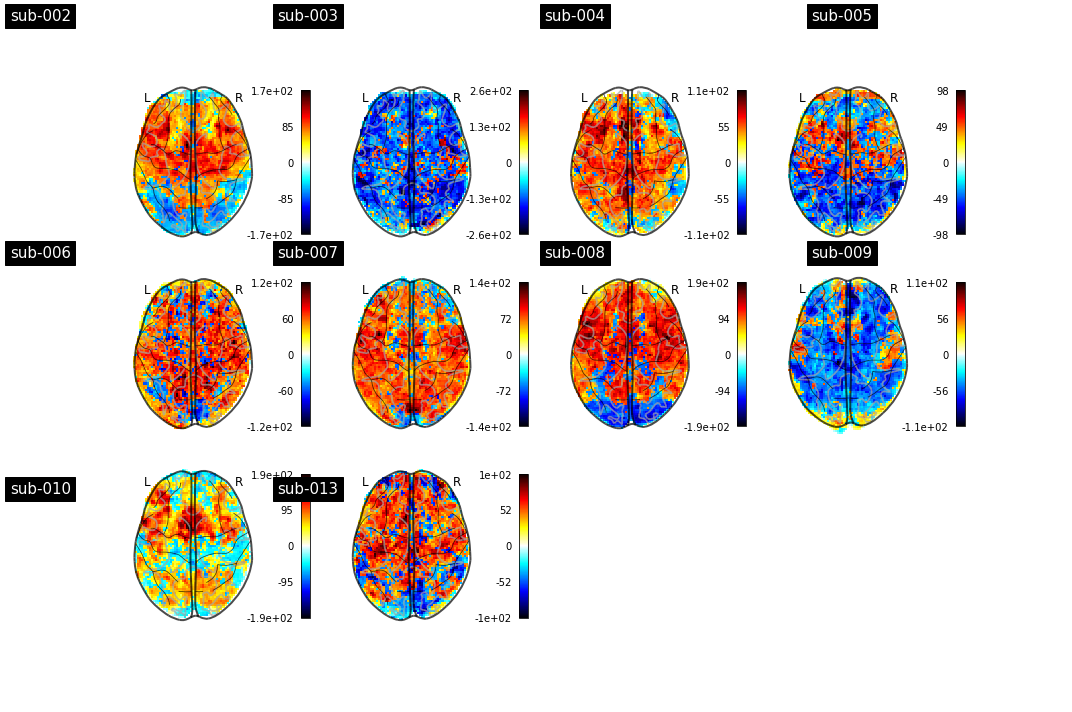

In [395]:
# Assuming `s_glm_out` is a dictionary with NIfTI-like images as values
# and the keys are the names of the corresponding maps.
c = 'internal'
plot_s_glm_out = s_glm_out[c]


num_keys = len(plot_s_glm_out.keys())
keys = list(plot_s_glm_out.keys())

# Determine subplot grid dimensions
rows = int(num_keys ** 0.5)
cols = (num_keys + rows - 1) // rows  # Ensure enough columns for all plots

# Create a figure for the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

# Flatten axes for easy indexing
axes = axes.flatten()

left_premotor_coords = (-40, -20, 60)


# Plot each stat map
for i, key in enumerate(list(plot_s_glm_out.keys())):
    ax = axes[i]
    # Plot the stat map corresponding to the current key
    '''
    plot_stat_map(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        cut_coords=left_premotor_coords,
        colorbar=True,
        display_mode='ortho'  # Adjust to your preferred display mode
    )
    '''
    # Plot the glass brain corresponding to the current key
    display = plot_glass_brain(
        plot_s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        colorbar=True,
        display_mode='z',  # Axial view only
        plot_abs=False  # Set to True if absolute values are preferred
    )
    
# Hide any unused subplots if keys are fewer than subplots
for j in range(len(keys), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


## no regressors 

/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/ipykernel_launcher.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


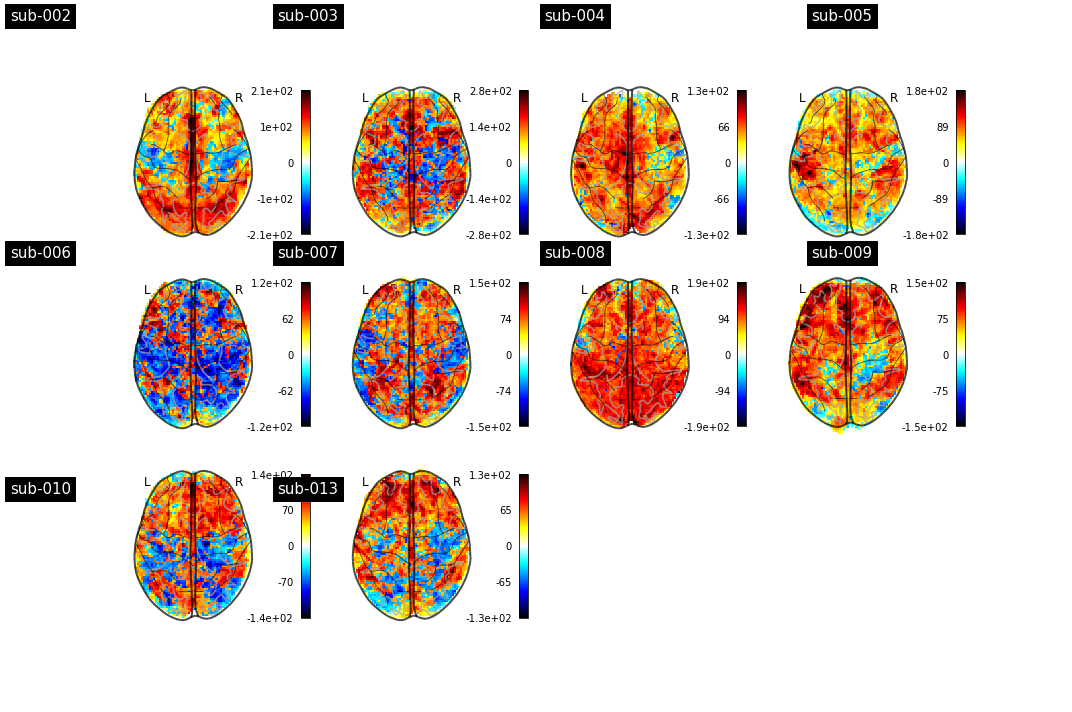

In [367]:
# Assuming `s_glm_out` is a dictionary with NIfTI-like images as values
# and the keys are the names of the corresponding maps.
num_keys = len(s_glm_out.keys())
keys = list(s_glm_out.keys())

# Determine subplot grid dimensions
rows = int(num_keys ** 0.5)
cols = (num_keys + rows - 1) // rows  # Ensure enough columns for all plots

# Create a figure for the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

# Flatten axes for easy indexing
axes = axes.flatten()

left_premotor_coords = (-40, -20, 60)


# Plot each stat map
for i, key in enumerate(list(s_glm_out.keys())):
    ax = axes[i]
    # Plot the stat map corresponding to the current key
    '''
    plot_stat_map(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        cut_coords=left_premotor_coords,
        colorbar=True,
        display_mode='ortho'  # Adjust to your preferred display mode
    )
    '''
    # Plot the glass brain corresponding to the current key
    display = plot_glass_brain(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        colorbar=True,
        display_mode='z',  # Axial view only
        plot_abs=False  # Set to True if absolute values are preferred
    )
    
# Hide any unused subplots if keys are fewer than subplots
for j in range(len(keys), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


## regressors in glm

/jukebox/pkgs/PYGER/base/envs/0.11.0/lib/python3.7/site-packages/ipykernel_launcher.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


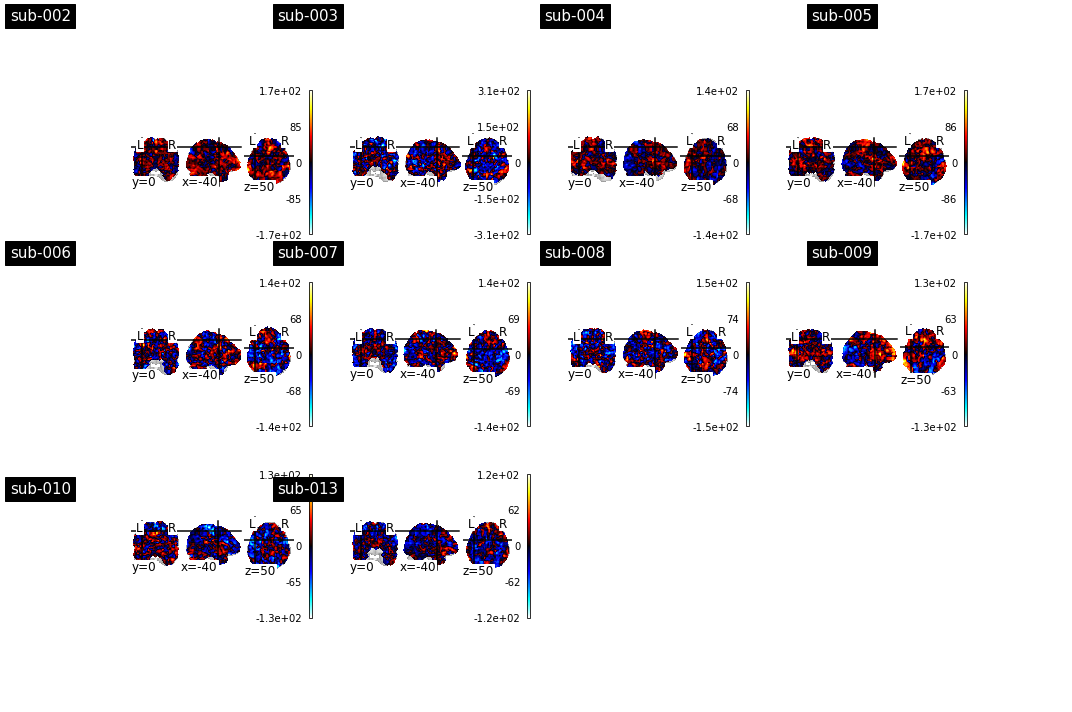

In [360]:
# Assuming `s_glm_out` is a dictionary with NIfTI-like images as values
# and the keys are the names of the corresponding maps.
num_keys = len(s_glm_out.keys())
keys = list(s_glm_out.keys())

# Determine subplot grid dimensions
rows = int(num_keys ** 0.5)
cols = (num_keys + rows - 1) // rows  # Ensure enough columns for all plots

# Create a figure for the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

# Flatten axes for easy indexing
axes = axes.flatten()

left_premotor_coords = (-40, 0, 50)


# Plot each stat map
for i, key in enumerate(list(s_glm_out.keys())):
    ax = axes[i]
    # Plot the stat map corresponding to the current key
    plot_stat_map(
        s_glm_out[key]['win1'],
        axes=ax,
        title=key,
        cut_coords=left_premotor_coords,
        colorbar=True,
        display_mode='ortho'  # Adjust to your preferred display mode
    )

# Hide any unused subplots if keys are fewer than subplots
for j in range(len(keys), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


In [220]:
events_across_mov_x = [i for i in events_across_mov]
len(events_across_mov_x)

3

In [ ]:
''' NOTES 
did we discard runs with no button presses correctly

'''